In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [4]:
image_cut = image[55:155, 0:1890]
image_error_cut = image_error[55:155, 0:1890]

Text(0.5, 0, 'wavelenght')

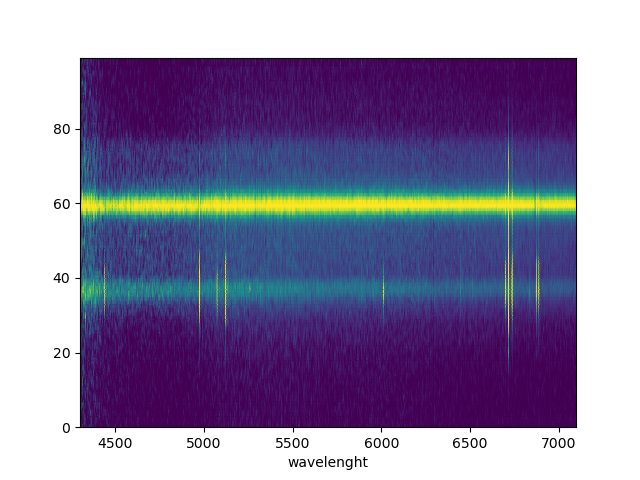

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [6]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

Text(0, 0.5, 'Flux [$10^{-16} erg/(cm^2 s \\AA )$]')

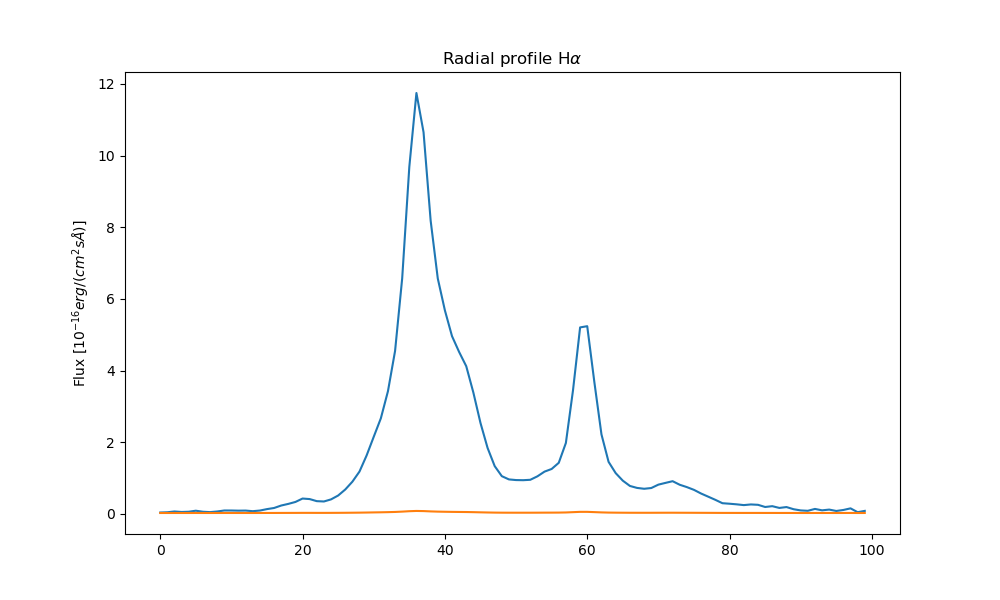

In [7]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'Radial profile H$\alpha$')
plt.ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')

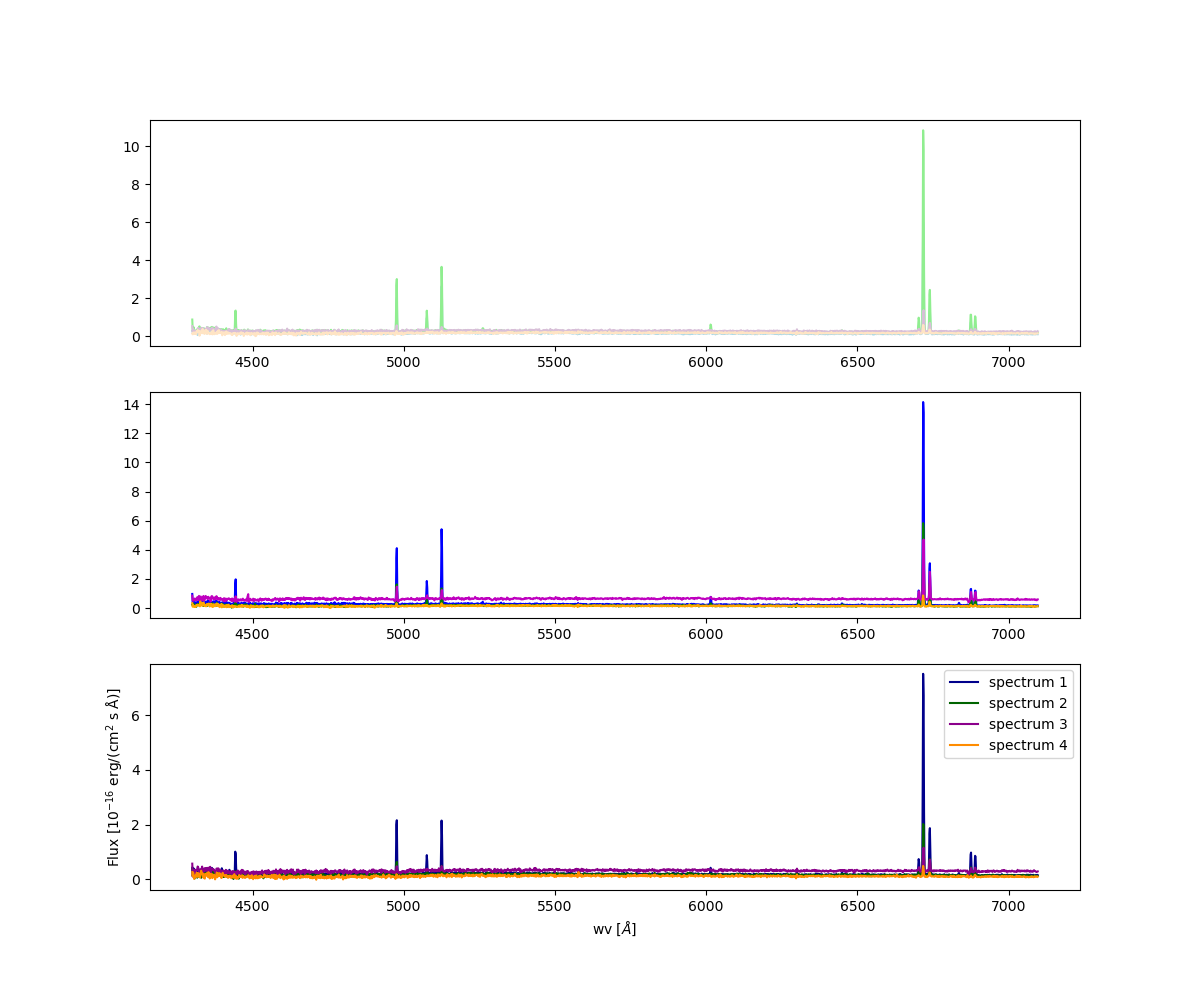

In [8]:
fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Fit_code/Halpha_fit.csv", index_col=0)
os.makedirs('4pix_center', exist_ok=True)

peaks = fit_HA.iloc[3].values

fig, ax = plt.subplots(3, 1, figsize=(12, 10))
spectra_1 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_2 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_3 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_1 = np.zeros((len(peaks), image_error_cut.shape[1]))
spectra_err_2 = np.zeros((len(peaks), image_error_cut.shape[1]))
spectra_err_3= np.zeros((len(peaks), image_error_cut.shape[1]))
data1 = []
data2 = []
data3 = []
colors1 = ['lightblue', 'lightgreen', 'thistle', 'bisque']
colors2 = ['blue', 'green', 'm', 'orange']
colors3 = ['darkblue', 'darkgreen', 'darkmagenta', 'darkorange']

#Cut one sigma 
for i in range(len(peaks)):
    mask1 = (x_axes > (peaks[i]-2)-4)*(x_axes < peaks[i]-2)
    mask2 = (x_axes > peaks[i]-2)*(x_axes < peaks[i]+2)
    mask3 = (x_axes > peaks[i]+2)*(x_axes < (peaks[i]+2)+4)
    spectra_1[i] = np.sum(image_cut[mask1, :], axis = 0)
    spectra_2[i] = np.sum(image_cut[mask2, :], axis = 0)
    spectra_3[i] = np.sum(image_cut[mask3, :], axis = 0)
    spectra_err_1[i] = np.sqrt(np.sum(image_error_cut[mask1, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    spectra_err_2[i] = np.sqrt(np.sum(image_error_cut[mask2, :]**2, axis = 0))
    spectra_err_3[i] = np.sqrt(np.sum(image_error_cut[mask3, :]**2, axis = 0))
    ax[0].plot(wv, spectra_1[i], color = colors1[i], label = f'spectrum {i+1}')
    ax[1].plot(wv, spectra_2[i], color = colors2[i], label = f'spectrum {i+1}')
    ax[2].plot(wv, spectra_3[i], color = colors3[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table1 = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_1[i].reshape(-1, 1), spectra_err_1[i].reshape(-1, 1)), axis=1)
    spectrum_table2 = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_2[i].reshape(-1, 1), spectra_err_2[i].reshape(-1, 1)), axis=1)
    spectrum_table3 = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_3[i].reshape(-1, 1), spectra_err_3[i].reshape(-1, 1)), axis=1)
    data1.append(spectrum_table1)
    data2.append(spectrum_table2)
    data3.append(spectrum_table3)
    
np.savetxt(os.path.join('4pix_center', 'Spectrum_sx_1.txt'), data1[0])
np.savetxt(os.path.join('4pix_center', 'Spectrum_sx_2.txt'), data1[1])
np.savetxt(os.path.join('4pix_center', 'Spectrum_sx_3.txt'), data1[2])
np.savetxt(os.path.join('4pix_center', 'Spectrum_sx_4.txt'), data1[3])

np.savetxt(os.path.join('4pix_center', 'Spectrum_center_1.txt'), data2[0])
np.savetxt(os.path.join('4pix_center', 'Spectrum_center_2.txt'), data2[1])
np.savetxt(os.path.join('4pix_center', 'Spectrum_center_3.txt'), data2[2])
np.savetxt(os.path.join('4pix_center', 'Spectrum_center_4.txt'), data2[3])

np.savetxt(os.path.join('4pix_center', 'Spectrum_dx_1.txt'), data3[0])
np.savetxt(os.path.join('4pix_center', 'Spectrum_dx_2.txt'), data3[1])
np.savetxt(os.path.join('4pix_center', 'Spectrum_dx_3.txt'), data3[2])
np.savetxt(os.path.join('4pix_center', 'Spectrum_dx_4.txt'), data3[3])

## S/N continuum
Fare segnale/rumore per ogni pixel e poi fai la media, questo per le tre regioni

In [9]:
import pandas as pd

mask_continuum_1 = (wv > 4500)*(wv < 4800)
mask_continuum_2 = (wv > 5300)*(wv < 5800)
mask_continuum_3 = (wv > 6400)*(wv < 6700)

SNR = []
for i in range(len(peaks)):  
    snr = []
    snr.append(np.mean(spectra_1[i, mask_continuum_1]/spectra_err_1[i, mask_continuum_1])) 
    snr.append(np.mean(spectra_1[i, mask_continuum_2]/spectra_err_1[i, mask_continuum_2])) 
    snr.append(np.mean(spectra_1[i, mask_continuum_3]/spectra_err_1[i, mask_continuum_3])) 
    SNR.append(snr)

SNR_array = np.array(SNR).T  #Trasponi per avere continuum come righe

mean_continuum = np.mean(SNR_array, axis=0)

df = pd.DataFrame(SNR_array, 
                  columns=[f'Spettro_{i+1}' for i in range(4)],
                  index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df.loc['Mean_Continuum'] = mean_continuum

print(df)

df_path = os.path.join('1Sigma', 'SNR_1s_continuum.csv')
df.to_csv(df_path, float_format='%.3f')

SNR = []
for i in range(len(peaks)):  
    snr = []
    snr.append(np.mean(spectra_2[i, mask_continuum_1]/spectra_err_2[i, mask_continuum_1])) 
    snr.append(np.mean(spectra_2[i, mask_continuum_2]/spectra_err_2[i, mask_continuum_2])) 
    snr.append(np.mean(spectra_2[i, mask_continuum_3]/spectra_err_2[i, mask_continuum_3])) 
    SNR.append(snr)

SNR_array = np.array(SNR).T  #Trasponi per avere continuum come righe

mean_continuum = np.mean(SNR_array, axis=0)

df = pd.DataFrame(SNR_array, 
                  columns=[f'Spettro_{i+1}' for i in range(4)],
                  index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df.loc['Mean_Continuum'] = mean_continuum

print(df)

df_path = os.path.join('2Sigma', 'SNR_2s_continuum.csv')
df.to_csv(df_path, float_format='%.3f')

SNR = []
for i in range(len(peaks)):  
    snr = []
    snr.append(np.mean(spectra_3[i, mask_continuum_1]/spectra_err_3[i, mask_continuum_1])) 
    snr.append(np.mean(spectra_3[i, mask_continuum_2]/spectra_err_3[i, mask_continuum_2])) 
    snr.append(np.mean(spectra_3[i, mask_continuum_3]/spectra_err_3[i, mask_continuum_3])) 
    SNR.append(snr)

SNR_array = np.array(SNR).T  #Trasponi per avere continuum come righe

mean_continuum = np.mean(SNR_array, axis=0)

df = pd.DataFrame(SNR_array, 
                  columns=[f'Spettro_{i+1}' for i in range(4)],
                  index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df.loc['Mean_Continuum'] = mean_continuum

print(df)

df_path = os.path.join('3Sigma', 'SNR_3s_continuum.csv')
df.to_csv(df_path, float_format='%.3f')

                Spettro_1  Spettro_2  Spettro_3  Spettro_4
Continuum_1      3.820610   6.557389   6.661046   3.562427
Continuum_2      7.000942  10.345354  11.898326   7.841658
Continuum_3      7.157739  11.319503  13.560956   9.210246
Mean_Continuum   5.993097   9.407416  10.706776   6.871444


OSError: Cannot save file into a non-existent directory: '1Sigma'

## S/N emission lines 

In [ ]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

In [ ]:
def SNR_line(wv, wv_line, spectra, peaks):
    left_region = (wv > wv_line-25)*(wv < wv_line-10) 
    right_region = (wv > wv_line+10)*(wv < wv_line+25) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
   # print(SNR)
   # print(Signal)
   # print(Noise)
    return SNR, Signal, Noise 

def SNR_HA_NII(wv, wv_line, spectra, peaks):
    left_region = (wv > 6675) & (wv < 6695)
    right_region = (wv > 6750) & (wv < 6775)
    clean_mask = left_region | right_region #But also for the two NII lines bc they are closed

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))

    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise 

In [ ]:
SNR_HB_1, signal_HB_1, noise_HB_1 = SNR_line(wv, l_HB, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_HB_1).reshape(-1, 1),
    np.array(signal_HB_1).reshape(-1, 1),
    np.array(noise_HB_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('1Sigma', 'SNR_HB_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HB_2, signal_HB_2, noise_HB_2 = SNR_line(wv, l_HB, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_HB_2).reshape(-1, 1),
    np.array(signal_HB_2).reshape(-1, 1),
    np.array(noise_HB_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('2Sigma', 'SNR_HB_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HB_3, signal_HB_3, noise_HB_3 = SNR_line(wv, l_HB, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_HB_3).reshape(-1, 1),
    np.array(signal_HB_3).reshape(-1, 1),
    np.array(noise_HB_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('3Sigma', 'SNR_HB_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_1, signal_SII_1, noise_SII_1 = SNR_line(wv, l_SII, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_SII_1).reshape(-1, 1),
    np.array(signal_SII_1).reshape(-1, 1),
    np.array(noise_SII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('1Sigma', 'SNR_SII_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2, signal_SII_2, noise_SII_2 = SNR_line(wv, l_SII, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_SII_2).reshape(-1, 1),
    np.array(signal_SII_2).reshape(-1, 1),
    np.array(noise_SII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('2Sigma', 'SNR_SII_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_3, signal_SII_3, noise_SII_3 = SNR_line(wv, l_SII, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_SII_3).reshape(-1, 1),
    np.array(signal_SII_3).reshape(-1, 1),
    np.array(noise_SII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('3Sigma', 'SNR_SII_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_1, signal_OIII_1, noise_OIII_1 = SNR_line(wv, l_OIII, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_OIII_1).reshape(-1, 1),
    np.array(signal_OIII_1).reshape(-1, 1),
    np.array(noise_OIII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('1Sigma', 'SNR_OIII_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2, signal_OIII_2, noise_OIII_2 = SNR_line(wv, l_OIII, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2).reshape(-1, 1),
    np.array(signal_OIII_2).reshape(-1, 1),
    np.array(noise_OIII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('2Sigma', 'SNR_OIII_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_3, signal_OIII_3, noise_OIII_3 = SNR_line(wv, l_OIII, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_OIII_3).reshape(-1, 1),
    np.array(signal_OIII_3).reshape(-1, 1),
    np.array(noise_OIII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('3Sigma', 'SNR_OIII_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_1, signal_HA_1, noise_HA_1 = SNR_HA_NII(wv, l_HA, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_HA_1).reshape(-1, 1),
    np.array(signal_HA_1).reshape(-1, 1),
    np.array(noise_HA_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('1Sigma', 'SNR_HA_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_2, signal_HA_2, noise_HA_2 = SNR_HA_NII(wv, l_HA, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_HA_2).reshape(-1, 1),
    np.array(signal_HA_2).reshape(-1, 1),
    np.array(noise_HA_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('2Sigma', 'SNR_HA_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_3, signal_HA_3, noise_HA_3 = SNR_HA_NII(wv, l_HA, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_HA_3).reshape(-1, 1),
    np.array(signal_HA_3).reshape(-1, 1),
    np.array(noise_HA_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('3Sigma', 'SNR_HA_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_1, signal_NII_1, noise_NII_1 = SNR_HA_NII(wv, l_NII, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_NII_1).reshape(-1, 1),
    np.array(signal_NII_1).reshape(-1, 1),
    np.array(noise_NII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('1Sigma', 'SNR_NII_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2, signal_NII_2, noise_NII_2 = SNR_HA_NII(wv, l_NII, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_NII_2).reshape(-1, 1),
    np.array(signal_NII_2).reshape(-1, 1),
    np.array(noise_NII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('2Sigma', 'SNR_NII_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_3, signal_NII_3, noise_NII_3 = SNR_HA_NII(wv, l_NII, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_NII_3).reshape(-1, 1),
    np.array(signal_NII_3).reshape(-1, 1),
    np.array(noise_NII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('3Sigma', 'SNR_NII_3s.csv')
df.to_csv(df_path, float_format='%.3f')